In [1]:
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.decomposition import PCA
import seaborn as sns

In [8]:
ds = load_dataset("YieumYoon/bimanual-center-basket-rblock-rlmerged-2", split="train")
# 
print(ds[0].keys())
print("features:", ds.column_names)
print("num rows:", len(ds))

dict_keys(['action', 'observation.state', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index'])
features: ['action', 'observation.state', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']
num rows: 105162


## A. Basic dataset stats & episode listing

In [9]:
# Cell 1: dataset stats and episodes
episode_counts = {}
for item in ds:
    ep = int(item["episode_index"])
    episode_counts[ep] = episode_counts.get(ep, 0) + 1

# convert to sorted list
eps = sorted(episode_counts.items(), key=lambda x: x[0])
print("Episode -> # frames (first 10 shown):", eps[:10])
print("Total episodes:", len(episode_counts))
print("Example row keys:", list(ds[0].keys()))



Episode -> # frames (first 10 shown): [(0, 763), (1, 632), (2, 701), (3, 703), (4, 842), (5, 666), (6, 679), (7, 600), (8, 653), (9, 600)]
Total episodes: 180
Example row keys: ['action', 'observation.state', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']


## B. Plot action trajectories (one episode)

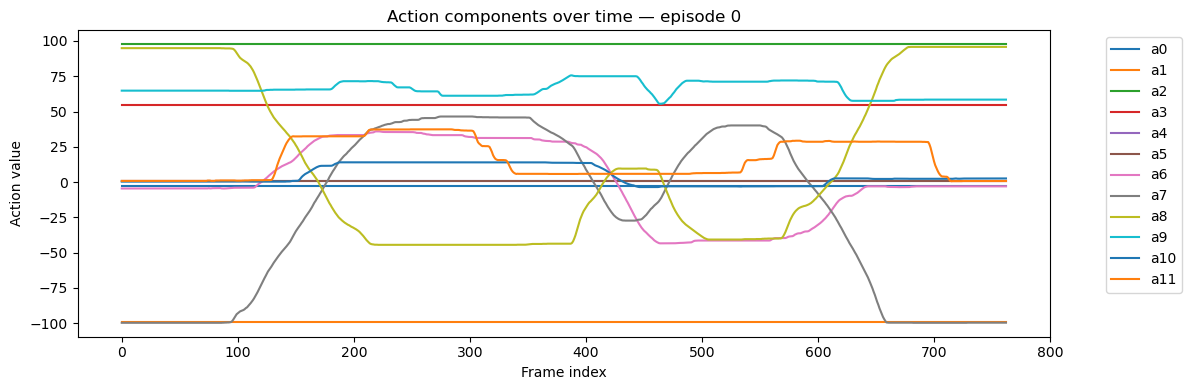

In [10]:
# Cell 2: plot action components for a given episode
def plot_action_episode(episode_id=0, show_legend=True):
    rows = [r for r in ds if int(r["episode_index"]) == episode_id]
    rows = sorted(rows, key=lambda x: int(x["frame_index"]))
    if not rows:
        print("No rows for episode", episode_id); return

    actions = np.array([np.array(r["action"], dtype=np.float32) for r in rows])
    t = np.arange(actions.shape[0])

    plt.figure(figsize=(12,4))
    plt.plot(t, actions)
    plt.title(f"Action components over time — episode {episode_id}")
    plt.xlabel("Frame index")
    plt.ylabel("Action value")
    if show_legend:
        plt.legend([f"a{i}" for i in range(actions.shape[1])], bbox_to_anchor=(1.05,1), loc='upper left')
    plt.tight_layout()
    plt.show()

# choose an episode available in your dataset
plot_action_episode(episode_id=0)


## C.Plot sensor/state trajectories

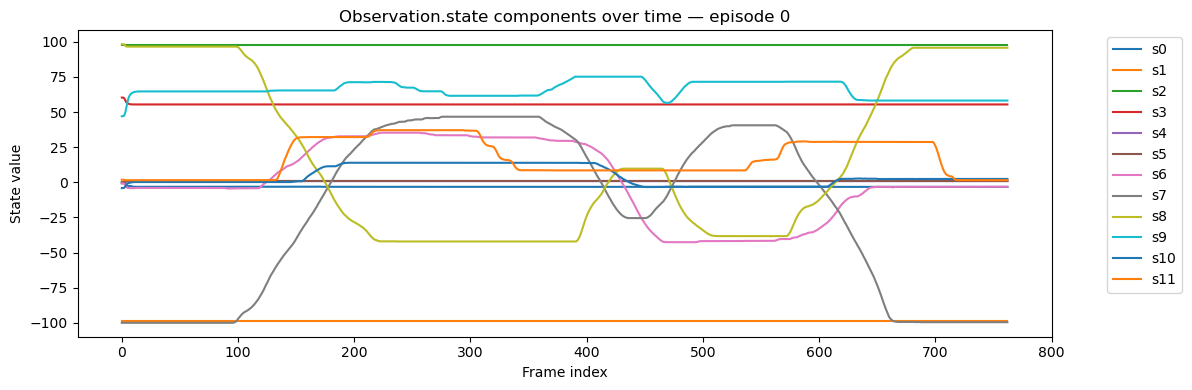

In [11]:
# Cell 3: plot observation.state components for an episode
def plot_state_episode(episode_id=0, n_components_plot=None):
    rows = [r for r in ds if int(r["episode_index"]) == episode_id]
    rows = sorted(rows, key=lambda x: int(x["frame_index"]))
    if not rows:
        print("No rows for episode", episode_id); return

    states = np.array([np.array(r["observation.state"], dtype=np.float32) for r in rows])
    t = np.arange(states.shape[0])

    plt.figure(figsize=(12,4))
    plt.plot(t, states)
    plt.title(f"Observation.state components over time — episode {episode_id}")
    plt.xlabel("Frame index")
    plt.ylabel("State value")
    if n_components_plot is None:
        plt.legend([f"s{i}" for i in range(states.shape[1])], bbox_to_anchor=(1.05,1), loc='upper left')
    else:
        plt.legend([f"s{i}" for i in range(n_components_plot)], bbox_to_anchor=(1.05,1), loc='upper left')
    plt.tight_layout()
    plt.show()

plot_state_episode(episode_id=0)



## D. Action magnitude vs state-change (alignment sanity check)

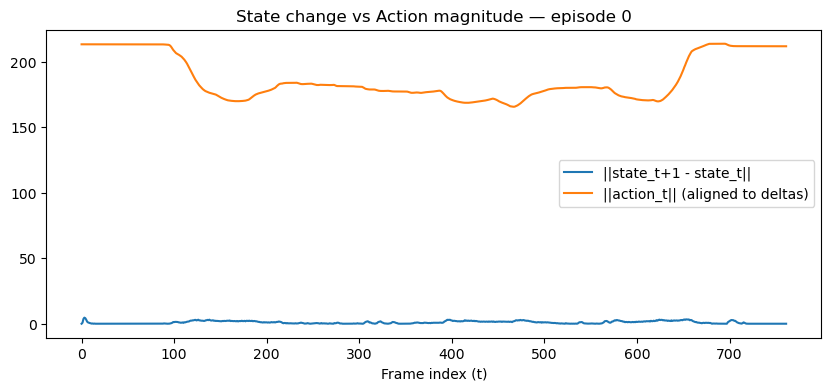

In [12]:
def action_vs_state_change(episode_id=0):
    rows = [r for r in ds if int(r["episode_index"]) == episode_id]
    rows = sorted(rows, key=lambda x: int(x["frame_index"]))
    if len(rows) < 2:
        print("Not enough frames for episode", episode_id); return

    states = np.array([np.array(r["observation.state"], dtype=np.float32) for r in rows])
    actions = np.array([np.array(r["action"], dtype=np.float32) for r in rows])

    # state delta magnitude (frame to frame)
    state_deltas = np.linalg.norm(np.diff(states, axis=0), axis=1)
    # action magnitude (drop last or first to align)
    action_mags = np.linalg.norm(actions[:-1], axis=1)

    plt.figure(figsize=(10,4))
    plt.plot(state_deltas, label="||state_t+1 - state_t||")
    plt.plot(action_mags, label="||action_t|| (aligned to deltas)")
    plt.legend()
    plt.xlabel("Frame index (t)")
    plt.title(f"State change vs Action magnitude — episode {episode_id}")
    plt.show()

action_vs_state_change(episode_id=0)


## E. Episode-level summary statistics and outliers

In [ ]:
#compute per-episode stats and show potential outliers
ep_stats = []
for ep, count in episode_counts.items():
    rows = [r for r in ds if int(r["episode_index"]) == ep]
    states = np.array([r["observation.state"] for r in rows], dtype=np.float32)
    actions = np.array([r["action"] for r in rows], dtype=np.float32)
    ep_stats.append({
        "episode": ep,
        "frames": len(rows),
        "state_mean_norm": float(np.mean(np.linalg.norm(states, axis=1))),
        "action_mean_norm": float(np.mean(np.linalg.norm(actions, axis=1))),
        "state_std": float(np.mean(np.std(states, axis=0))),
    })

# sort and show
ep_stats = sorted(ep_stats, key=lambda x: x["frames"], reverse=True)
import pandas as pd
df_stats = pd.DataFrame(ep_stats)
display(df_stats.head(20))

# quick plots
plt.figure(figsize=(10,3))
plt.hist(df_stats["frames"], bins=30)
plt.title("Distribution of frames per episode")
plt.xlabel("Frames")
plt.ylabel("Count")
plt.show()


## F. correlation heatmap of state & action components (sampled)


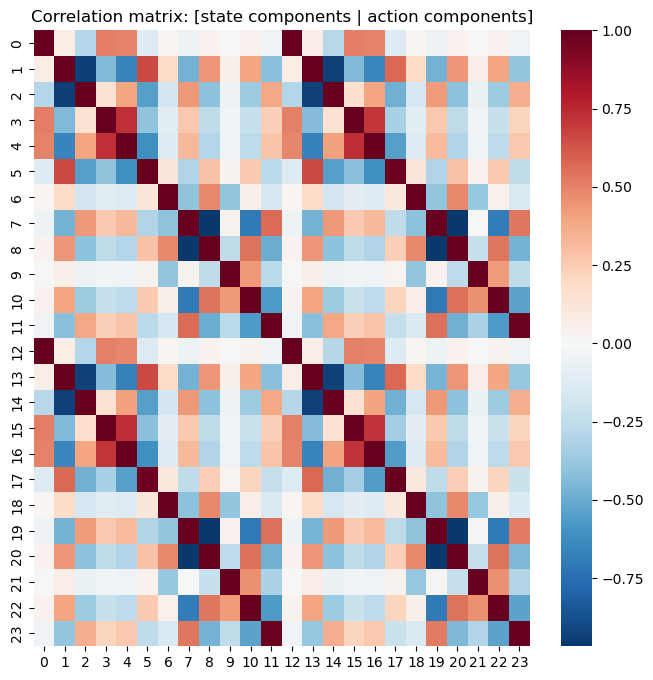

In [13]:
def corr_heatmap(n_samples=2000):
    idxs = np.random.choice(len(ds), size=min(n_samples, len(ds)), replace=False)
    states = np.array([np.array(ds[i]["observation.state"], dtype=np.float32) for i in idxs])
    actions = np.array([np.array(ds[i]["action"], dtype=np.float32) for i in idxs])
    combined = np.hstack([states, actions])
    corr = np.corrcoef(combined, rowvar=False)
    plt.figure(figsize=(8,8))
    sns.heatmap(corr, cmap="RdBu_r", center=0)
    plt.title("Correlation matrix: [state components | action components]")
    plt.show()

corr_heatmap(n_samples=1000)


## G. PCA visualization of states (sampled frames)

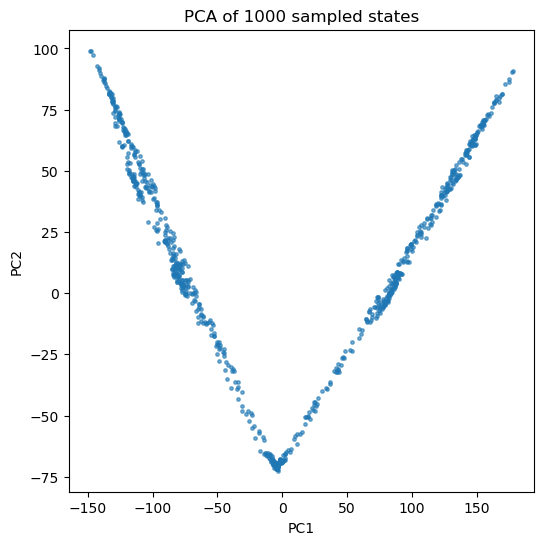

In [14]:
# Cell 6: compute PCA on sampled states to inspect clusters
def sample_and_pca(n_samples=2000):
    # sample random indices
    idxs = np.random.choice(len(ds), size=min(n_samples, len(ds)), replace=False)
    states = np.array([np.array(ds[i]["observation.state"], dtype=np.float32) for i in idxs])
    pca = PCA(n_components=2)
    proj = pca.fit_transform(states)
    plt.figure(figsize=(6,6))
    plt.scatter(proj[:,0], proj[:,1], s=6, alpha=0.6)
    plt.title(f"PCA of {states.shape[0]} sampled states")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

sample_and_pca(n_samples=1000)
